# H2-DRI-EAF steel NPV simulation

Run the Monte Carlo simulation for H2-DRI-EAF steel and visualize its total NPV, LPM, and LCOS (steel LCOX) distributions. The NPV summary also reports the number and share of simulations with non-negative versus negative NPV.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from steel.steel_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_RETROFIT_BAU_MODE,
    DEFAULT_SAMPLE_SIZE,
    simulate_steel_results,
)

from npv_summary import summarize_metric_signs
from npv_summary_plots import plot_financial_metric_distribution


In [2]:
TECHNOLOGY = "h2_dri_eaf"
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED
RETROFIT_BAU_MODE = DEFAULT_RETROFIT_BAU_MODE

results_by_technology = simulate_steel_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=(TECHNOLOGY,),
    retrofit_bau_mode=RETROFIT_BAU_MODE,
)
simulation = results_by_technology[TECHNOLOGY]
results = pd.DataFrame(simulation)
results.head()


,run_id,technology,technology_type,retrofit_bau_mode,annual_output_tcs,lifetime_years,capex_eur_per_tcs,fixed_opex_eur_per_tcs,variable_opex_eur_per_tcs,fuel_type,...,annual_electricity_cost_eur,annual_transport_and_storage_cost_eur,annual_emissions_cost_eur,annual_total_cost_eur,annual_net_cash_flow_eur,npv_eur,discounted_lifetime_output_tcs,present_value_total_cost_eur,lcos_eur_per_tcs,levelized_profit_margin_eur_per_tcs
0,0,h2_dri_eaf,absolute,not_applicable,1000000.0,20.0,667.301549,30.273892,324.767479,green_hydrogen_and_charcoal,...,6.573691e+07,0.0,497356.824535,8.508626e+08,-1.008626e+08,-1.657585e+09,9.818147e+06,9.021196e+09,918.828728,-168.828728
1,1,h2_dri_eaf,absolute,not_applicable,1000000.0,20.0,650.846405,34.934217,351.352778,green_hydrogen_and_charcoal,...,7.017167e+07,0.0,508486.106574,8.513703e+08,-1.013703e+08,-1.646115e+09,9.818147e+06,9.009726e+09,917.660448,-167.660448
2,2,h2_dri_eaf,absolute,not_applicable,1000000.0,20.0,637.501949,29.652340,316.213360,green_hydrogen_and_charcoal,...,1.228792e+08,0.0,461144.906283,8.717566e+08,-1.217566e+08,-1.832926e+09,9.818147e+06,9.196537e+09,936.687579,-186.687579
3,3,h2_dri_eaf,absolute,not_applicable,1000000.0,20.0,491.231581,27.987805,323.003479,green_hydrogen_and_charcoal,...,1.209862e+08,0.0,516152.138608,8.588043e+08,-1.088043e+08,-1.559488e+09,9.818147e+06,8.923099e+09,908.837307,-158.837307
4,4,h2_dri_eaf,absolute,not_applicable,1000000.0,20.0,479.805221,34.476572,331.263442,green_hydrogen_and_charcoal,...,7.803258e+07,0.0,497800.351082,8.478518e+08,-9.785181e+07,-1.440529e+09,9.818147e+06,8.804139e+09,896.721035,-146.721035


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
lcos_eur_per_tcs = results["lcos_eur_per_tcs"]
levelized_profit_margin_eur_per_tcs = results["levelized_profit_margin_eur_per_tcs"]

summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        lcos_eur_per_tcs.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "LCOS EUR/tCS"
        ),
        levelized_profit_margin_eur_per_tcs.describe(
            percentiles=[0.05, 0.5, 0.95]
        ).rename("Levelized profit margin EUR/tCS"),
    ],
    axis=1,
)

npv_signs = summarize_metric_signs(npv_million_eur)
npv_sign_summary = pd.DataFrame(
    {
        "NPV category": ["Non-negative (NPV >= 0)", "Negative (NPV < 0)"],
        "Simulation count": [
            npv_signs["non_negative_count"],
            npv_signs["negative_count"],
        ],
        "Simulation share": [
            npv_signs["non_negative_share"],
            1.0 - npv_signs["non_negative_share"],
        ],
    }
)

display(summary)
display(npv_sign_summary)


,NPV million EUR,LCOS EUR/tCS,Levelized profit margin EUR/tCS
count,100000.000000,100000.000000,100000.000000
mean,-1844.544498,937.870931,-187.870931
std,521.351179,53.100769,53.100769
min,-3965.085239,793.353678,-403.852690
5%,-2766.863306,857.615588,-281.811139
50%,-1802.101130,933.547981,-183.547981
95%,-1056.585709,1031.811139,-107.615588
max,-425.652799,1153.852690,-43.353678


,NPV category,Simulation count,Simulation share
0,Non-negative (NPV >= 0),0,0.0
1,Negative (NPV < 0),100000,1.0


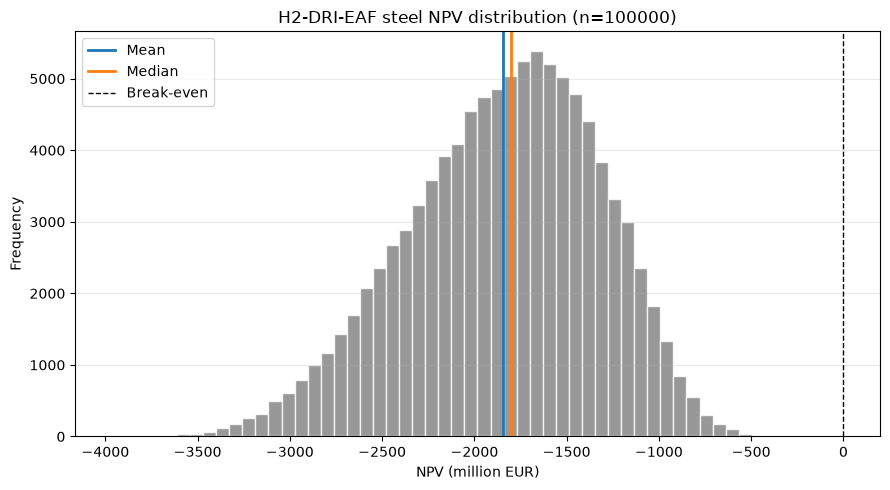

In [4]:
plot_financial_metric_distribution(
    npv_million_eur,
    title=f"H2-DRI-EAF steel NPV distribution (n={SAMPLE_SIZE})",
    x_axis_label="NPV (million EUR)",
    color="tab:gray",
    show_break_even=True,
)
plt.show()


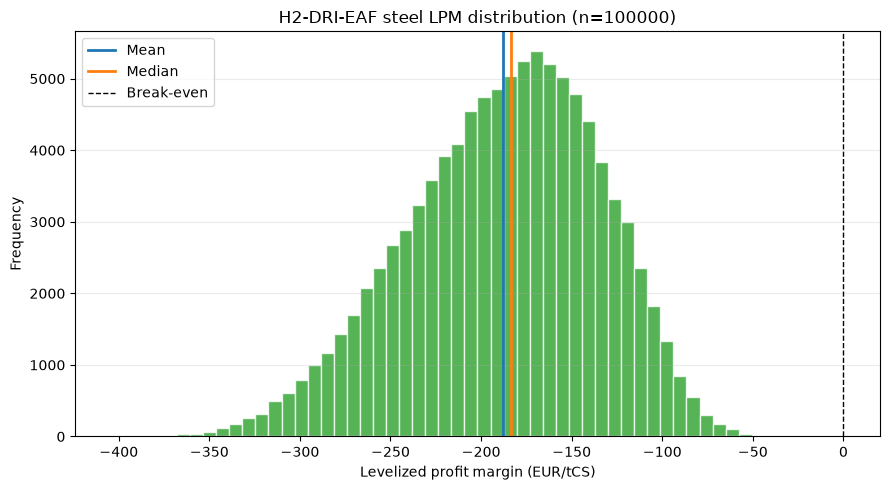

In [5]:
plot_financial_metric_distribution(
    levelized_profit_margin_eur_per_tcs,
    title=f"H2-DRI-EAF steel LPM distribution (n={SAMPLE_SIZE})",
    x_axis_label="Levelized profit margin (EUR/tCS)",
    color="tab:green",
    show_break_even=True,
)
plt.show()


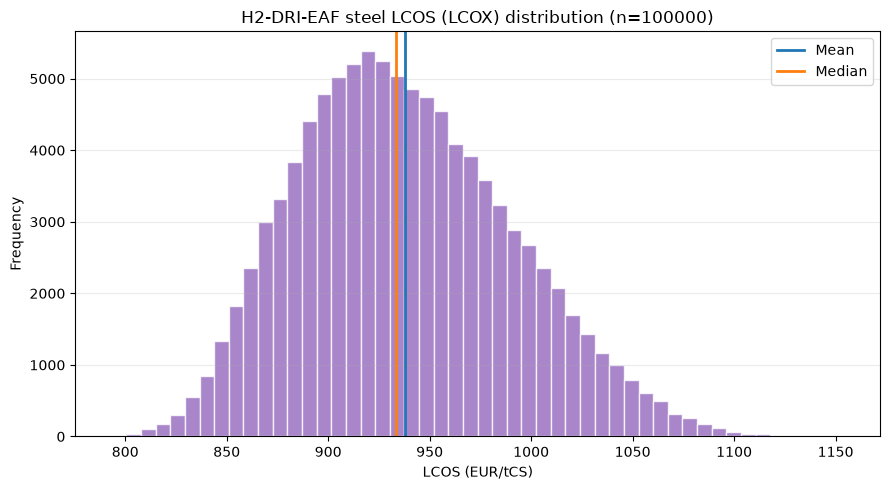

In [6]:
plot_financial_metric_distribution(
    lcos_eur_per_tcs,
    title=f"H2-DRI-EAF steel LCOS (LCOX) distribution (n={SAMPLE_SIZE})",
    x_axis_label="LCOS (EUR/tCS)",
    color="tab:purple",
)
plt.show()


In [7]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_electricity_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur"
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")


annual_revenue_eur             750.000000
annual_fixed_opex_eur           31.002945
annual_variable_opex_eur       334.610012
annual_fuel_cost_eur           406.945840
annual_electricity_cost_eur    104.513490
annual_emissions_cost_eur        0.533959
annual_net_cash_flow_eur      -127.606245
Name: Mean annual value, million EUR, dtype: float64